<img src="logo.png" alt="Vegeta" width="240">

# Pekari Rover — a small tracked rover: machine, ground, drive train and track

**Pekari** (the peccary, a small wild pig that goes everywhere) is a tracked (caterpillar) rover in the class of the
wheeled rover of notebook 11: about 19 kg empty, a 5 kg payload in the basket on its roof (the default
configuration), a hull box between two track modules. Each track: a rear drive sprocket, a front idler on a
tensioner slide, four road wheels in pairs on bogies, a return roller, and a belt of 51 hinged PA6-GF30 links with
steel pins, grousers below and a guide horn on top. One gearmotor per track (a 100 W BLDC through a 16:1 two-stage
planetary) steers it by skidding.

This notebook is stage 1 of the Pekari plan (todo 5j.1–5j.3): the machine and its numbers, the ground it can cross,
the gears and the track. The arms, the drive-type comparison and the terrain race in MuJoCo come later (5j.4–5j.7).

```
CAD (Dedalus): hull + basket, track modules, sprocket, idler, road wheel, link, pinion ─► mass budget, CG
masses ─► ground pressure, MMP (Rowland) ─► Bekker–Wong sinkage, compaction, thrust–slip per soil (terramechanics)
resistance (soil, internal, grade, drag) vs the gearmotor line ─► top speed per grade, acceleration, range, max grade
CG + track envelope ─► tip-over angles, side slope, step, trench; road-wheel loads rigid vs bogies
climb + top speed ─► gear ratio ─► planetary 4:1 × 4:1 ─► Lewis + Hertz ─► FEA on the sun pinion (Talos)
mission ─► torque history ─► load levels × mesh cycles ─► tooth life (Chronos); rainflow ─► output shaft
belt: tension, sag, derail, pin and link stresses ─► FEA on the link and the sprocket ─► link fatigue, hinge wear
skid steering: turning moment, minimum radius, clutch-brake vs regenerative power
MuJoCo (Chiron): tracks as rollers ─► 3 m, a 90° turn, 2 m on rough ground with a log ─► path, forces, movie
```

Every input is explicit and coarse (soil values from Wong's tables, catalogue-class motors, assumed internal loss and
wear rates); the numbers are for comparing and sizing. Compare, record, then test on a real field.

In [1]:
# DEBUG: test the notebook end to end before the full run. On: FEA and CFD are mocked (vegeta.mock: fixed numbers,
# seconds instead of hours, the result cache off). Turn it on here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute <notebook>.ipynb --output <notebook>-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [2]:
import json, math, shutil, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from vegeta import dedalus, talos, chronos
from vegeta.dedalus import viz as dviz
from vegeta.talos import viz as tviz
sys.path.insert(0, "designs")
import actuators as act                   # the shared actuator / motor / joint library (designs/actuators.py)
import gears, tracks, terramechanics as tm
import pekari_rover_robot as prr

RUNS = Path("_runs/pekari_rover"); shutil.rmtree(RUNS, ignore_errors=True); RUNS.mkdir(parents=True)
OUT = Path("output/30_pekari_rover"); OUT.mkdir(parents=True, exist_ok=True)
design_file = RUNS / "pekari_rover.py"
shutil.copy(Path("designs/pekari_rover.py"), design_file)
design = dedalus.load_design(f"{design_file}:PekariRover")
G = 9.81
SPEC = pd.Series({"mass, loaded [kg]": "≤ 25", "payload in the basket [kg]": 5.0, "top speed [m/s]": 1.5,
                  "climb, dry ground": "30°", "ground pressure [kPa]": "< 5 (a person on foot: 15-20)",
                  "endurance at 1 m/s [h]": "≥ 3", "steering": "skid, pivot turn on hard ground"},
                 name="Pekari Rover — targets")
display(SPEC.to_frame())
pd.DataFrame(design.params.table()).set_index("name")

,Pekari Rover — targets
"mass, loaded [kg]",≤ 25
payload in the basket [kg],5.0
top speed [m/s],1.5
"climb, dry ground",30°
ground pressure [kPa],< 5 (a person on foot: 15-20)
endurance at 1 m/s [h],≥ 3
steering,"skid, pivot turn on hard ground"


,default,units,min,max,description
name,,,,,
part,rover,NaN,NaN,NaN,what to build
hull_length,560.0,mm,100.0,NaN,
hull_width,300.0,mm,50.0,NaN,
hull_height,140.0,mm,30.0,NaN,
hull_chamfer,15.0,mm,1.0,NaN,
ground_clearance,90.0,mm,20.0,NaN,hull floor above the ground
sensor_box,80.0,mm,0.0,NaN,"sensor block on the hull roof, front (0 = none)"
basket_length,380.0,mm,0.0,NaN,payload basket on the roof (the default config...
basket_width,260.0,mm,0.0,NaN,


## 1. The machine

The CAD builds the rover and each part on its own; the mass budget takes the hull's sheet from the CAD area, the
links, sprockets and wheels from the CAD volumes (the wheels ribbed to 35 % of solid), the gearmotors from the
catalogue and the rest from a parts list. The battery goes where it puts the empty rover's CG over the middle of
the road wheels.

,volume_cm3,area_cm2,size_mm
rover,32143.655816,21356.902669,719 × 492 × 350
hull,23769.0,5813.558441,560 × 300 × 180
basket,401.0535,5280.18,400 × 280 × 120
track_module,3986.801158,6563.025593,719 × 96 × 210
sprocket,295.737287,732.798251,133 × 62 × 133
idler,655.493307,558.889333,110 × 80 × 110
road_wheel,244.572988,307.561921,70 × 80 × 70
track_link,25.768419,98.281426,42 × 80 × 26
pinion,1.384374,13.818547,16 × 10 × 16


/home/user/vegeta/vegeta-cli/src/vegeta/dedalus/viz.py:108: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


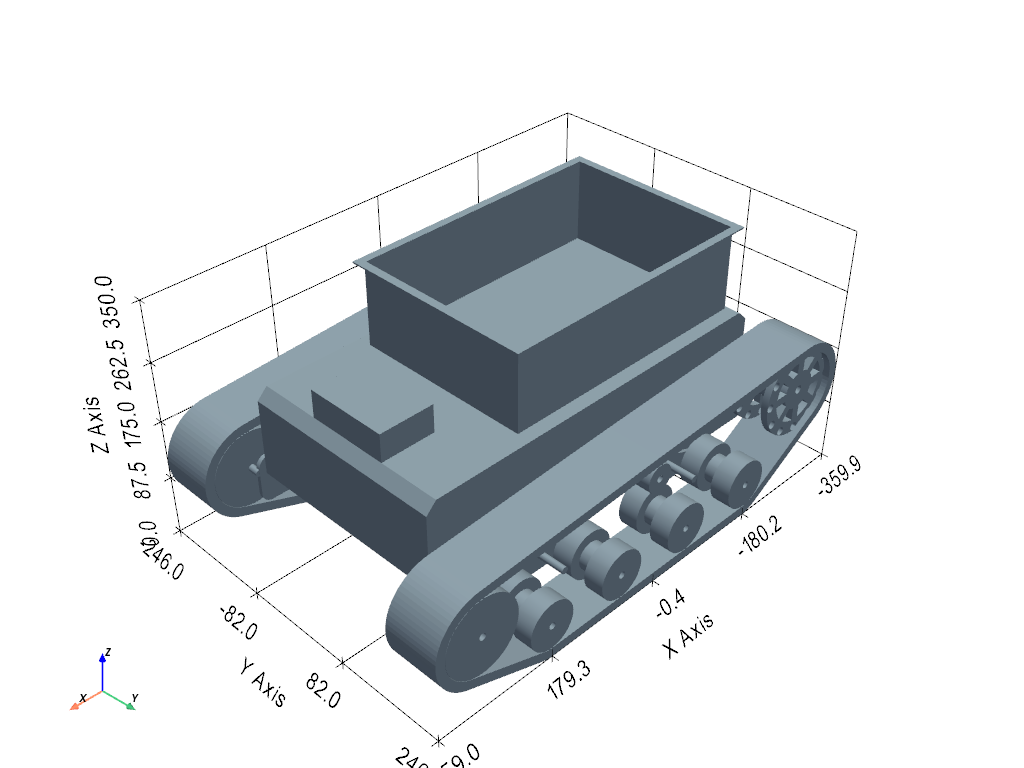

In [3]:
p = design.resolve()
PARTS = ("rover", "hull", "basket", "track_module", "sprocket", "idler", "road_wheel", "track_link", "pinion")
parts = {k: design.generate(part=k) for k in PARTS}
cad = {k: g.export(RUNS / "cad" / k, stl_tolerance=0.1) for k, g in parts.items()}
display(pd.DataFrame({k: {"volume_cm3": g.measure()["volume"] / 1e3, "area_cm2": g.measure()["surface_area"] / 1e2,
                          "size_mm": " × ".join(f"{d:.0f}" for d in g.measure()["dimensions"])}
                      for k, g in parts.items()}).T)
dviz.show(dviz.plot3d(parts["rover"]))

In [4]:
# the stored CAD numbers (pekari_rover_robot.CAD) against this build: they drive the mass budget
fresh = prr.cad_numbers(recompute=True)
drift = {k: (abs(fresh[k] - v) / v if not isinstance(v, tuple) else max(abs(a - b) for a, b in zip(fresh[k], v)))
         for k, v in prr.CAD.items()}
assert all(d < 0.02 for k, d in drift.items() if not isinstance(prr.CAD[k], tuple)), drift
g = prr.geometry(p)
budget = pd.Series(prr.mass_budget(p), name="kg")
cgs = prr.cg(p)
display(budget.to_frame().style.format("{:.2f}"))
print(f"empty {budget.sum():.2f} kg, loaded {cgs['loaded']['mass_kg']:.2f} kg; battery at x = {cgs['battery_x'] * 1000:.0f} mm")
geo = pd.Series({"track width b [mm]": g["b"] * 1e3, "contact length L [mm]": g["L"] * 1e3, "gauge B [mm]": g["B"] * 1e3,
                 "L / B (skid steering wants ≤ 1.8)": g["L"] / g["B"], "sprocket pitch radius [mm]": g["r_sprocket"] * 1e3,
                 "belt (pin line) [mm]": g["belt_length"] * 1e3, "links per track": g["links"],
                 "idler take-up [mm]": g["take_up"] * 1e3 / 2, "CG empty x, z [mm]": f"{cgs['empty']['x']*1e3:.0f}, {cgs['empty']['z']*1e3:.0f}",
                 "CG loaded x, z [mm]": f"{cgs['loaded']['x']*1e3:.0f}, {cgs['loaded']['z']*1e3:.0f}",
                 **{f"overall {k} [mm]": v * 1e3 for k, v in g["overall"].items()}}, name="geometry")
display(geo.to_frame())

,kg
"hull shell, 1.5 mm Al 6061 (from CAD area)",2.35
"track links 2x51 (PA6-GF30, from CAD)",3.57
"track pins 2x51 (steel, d 5 mm)",1.26
"sprockets 2x (PA6-GF30, ribbed, from CAD)",0.28
"idlers 2x (PA6-GF30, ribbed, from CAD)",0.62
"road wheels 2x4 (PA6-GF30, ribbed, from CAD)",0.93
track drives 2x (pekari drive 16:1 planetary; 0.80 kg each),1.60
"basket (1.5 mm Al 5754, from CAD)",1.07
battery 24 V 10 Ah LiFePO4 (240 Wh),2.30
"computer, motor controllers, radio, IMU",0.80


empty 18.99 kg, loaded 23.99 kg; battery at x = 28 mm


,geometry
track width b [mm],80.0
contact length L [mm],430.0
gauge B [mm],412.0
L / B (skid steering wants ≤ 1.8),1.043689
sprocket pitch radius [mm],59.887401
belt (pin line) [mm],1561.429242
links per track,51
idler take-up [mm],9.785379
"CG empty x, z [mm]","0, 139"
"CG loaded x, z [mm]","-15, 169"


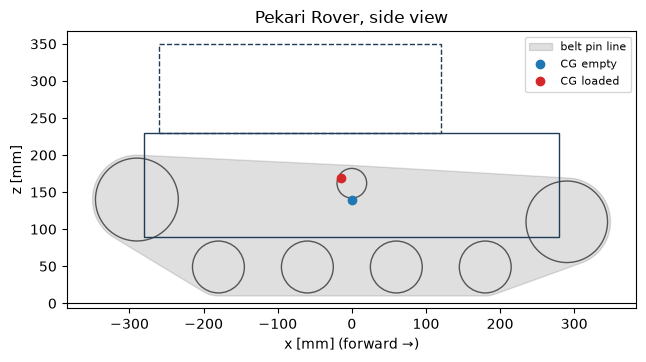

In [5]:
# side view: the belt's pin line around the sprocket, idler, road wheels and return roller, and the CGs
from importlib import import_module
pk = import_module("pekari_rover")
fig, ax = plt.subplots(figsize=(10, 3.6))
poly = np.array(pk._hull_of_circles([(x * 1e3, z * 1e3, r * 1e3) for x, z, r in g["belt_circles"]], 180))
ax.fill(poly[:, 0], poly[:, 1], color="#2b2b2b", alpha=0.15, label="belt pin line")
for (x, z, r), lab in zip(g["belt_circles"], ("sprocket", "idler", "road wheel", "road wheel", "return roller")):
    ax.add_patch(plt.Circle((x * 1e3, z * 1e3), r * 1e3 - p["link_thickness"] / 2, fill=False, color="#555"))
for x in g["wheel_x"][1:-1]:
    ax.add_patch(plt.Circle((x * 1e3, g["wheel_z"] * 1e3), g["d_wheel"] * 500, fill=False, color="#555"))
roof = p["ground_clearance"] + p["hull_height"]
ax.add_patch(plt.Rectangle((-p["hull_length"] / 2, p["ground_clearance"]), p["hull_length"], p["hull_height"], fill=False, color="#1f3b5a"))
ax.add_patch(plt.Rectangle((p["basket_x"] - p["basket_length"] / 2, roof), p["basket_length"], p["basket_height"], fill=False, color="#1f3b5a", ls="--"))
for lab, c, col in (("CG empty", cgs["empty"], "#1f77b4"), ("CG loaded", cgs["loaded"], "#d62728")):
    ax.plot(c["x"] * 1e3, c["z"] * 1e3, "o", color=col, label=lab)
ax.axhline(0, color="k", lw=0.8)
ax.set(aspect="equal", xlabel="x [mm] (forward →)", ylabel="z [mm]", title="Pekari Rover, side view")
ax.legend(loc="upper right", fontsize=8)
fig.savefig(OUT / "side_view.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Ground pressure and soil

The nominal ground pressure W / (2 b L) spreads the load evenly; under small road wheels the belt carries it in
peaks, which Rowland's mean maximum pressure (MMP) estimates. Bekker's law p = (k_c / b + k_φ) zⁿ turns pressure into
sinkage, and the rut is the compaction resistance. The same load on the four 110 × 40 mm wheels of notebook 11's
rover shows what the tracks buy.

In [6]:
W = cgs["loaded"]["mass_kg"] * G
W0 = cgs["empty"]["mass_kg"] * G
p_nom = tracks.ground_pressure(W, g["b"], g["L"])
mmp = tm.mmp_rowland(W, g["n_wheels"], g["b"], g["d_wheel"], g["pitch"])
WHEEL = {"D": 0.110, "b": 0.040}                        # the wheeled rover of notebook 11
print(f"loaded {W:.0f} N: nominal {p_nom / 1e3:.2f} kPa, MMP {mmp / 1e3:.1f} kPa")
display(tm.table())
rows = {}
for name, s in tm.SOILS.items():
    rows[name] = {"track sinkage [mm]": tm.track_sinkage(W / 2, g["b"], g["L"], s) * 1e3,
                  "track compaction R [N]": 2 * tm.compaction_resistance_track(W / 2, g["b"], g["L"], s),
                  "wheel sinkage [mm]": tm.wheel_sinkage(W / 4, WHEEL["b"], WHEEL["D"], s) * 1e3,
                  "wheels compaction R [N]": 4 * tm.wheel_compaction_resistance(W / 4, WHEEL["b"], WHEEL["D"], s)}
soil_tab = pd.DataFrame(rows).T
soil_tab["R / W track"] = soil_tab["track compaction R [N]"] / W
soil_tab["R / W wheels"] = soil_tab["wheels compaction R [N]"] / W
display(soil_tab.style.format("{:.3g}"))

loaded 235 N: nominal 3.42 kPa, MMP 9.9 kPa


,n,k_c [kN/m^(n+1)],k_phi [kN/m^(n+2)],c [kPa],phi [deg],K [mm],mu,C_rr,rigid,source
dry sand,1.1,0.99,1528.43,1.04,28.0,25.0,0.6,0.1,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
sandy loam,0.7,5.27,1515.04,1.72,29.0,25.0,0.6,0.06,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
clayey soil,0.5,13.19,692.15,4.14,13.0,10.0,0.4,0.08,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
heavy clay,0.13,12.7,1555.95,68.95,34.0,6.0,0.6,0.05,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
lean clay,0.2,16.43,1724.69,68.95,20.0,6.0,0.5,0.05,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
snow,1.6,4.37,196.72,1.03,19.7,40.0,0.3,0.06,False,"Wong, Theory of Ground Vehicles, Table 2.3 (Be..."
mud,1.0,2.0,50.0,2.0,6.0,10.0,0.25,0.1,False,"assumed: saturated clay, an order of magnitude..."
asphalt,1.0,0.0,inf,0.0,0.0,10.0,0.8,0.015,True,handbook: rubber on dry asphalt
gravel,1.0,0.0,inf,0.0,0.0,10.0,0.6,0.03,True,handbook: rubber on loose gravel
grass,1.0,0.0,inf,0.0,0.0,10.0,0.5,0.06,True,handbook: rubber on dry short grass


,track sinkage [mm],track compaction R [N],wheel sinkage [mm],wheels compaction R [N],R / W track,R / W wheels
dry sand,3.87,1.01,34.2,98.6,0.00428,0.419
sandy loam,0.156,0.0502,9.01,51.7,0.000213,0.22
clayey soil,0.0159,0.00581,5.21,41,2.47e-05,0.174
heavy clay,1.7e-18,8.23e-19,0.0729,5.6,3.5e-21,0.0238
lean clay,1.75e-11,7.98e-12,0.162,8.07,3.39e-14,0.0343
snow,68.2,14.4,191,256,0.061,1.09
mud,45.6,12.5,164,216,0.053,0.916
asphalt,0,0,0,0,0,0
gravel,0,0,0,0,0,0
grass,0,0,0,0,0,0


## 3. Drive: resistance, traction, speed, range (5j.1)

Resistance = compaction (soil) or the belt's rolling resistance (hard ground) + the track's internal loss
f_in = 0.035 + 0.002 v (an assumption to measure first) + grade + drag. Traction: μW on hard ground, the soil's shear
strength with the Janosi–Hanamoto slip law on soft ground. Each track has one gearmotor on its linear torque–speed
line, its tractive force at the sprocket's pitch radius.

In [7]:
CdA = 0.5 * 0.25                                         # drag: Cd ~1 on the 0.5 × 0.25 m front, halved (tracks shield)
drive = act.get(prr.DRIVE)
motor = act.get(prr.MOTOR)
r_s = g["r_sprocket"]
w0 = drive.no_load_rpm * 2 * math.pi / 60

def drive_force(v, n=2):
    """Tractive force [N] of ``n`` gearmotors at the belt speed v (the linear torque–speed line)."""
    return n * drive.stall_Nm * np.clip(1 - np.asarray(v) / (w0 * r_s), 0, None) / r_s

def max_grade(soil, Wt):
    """Steepest grade [deg] where the ground's traction still covers the resistance (slip 30 %)."""
    for th in np.arange(0, 60.01, 0.25):
        need = tracks.resistance(Wt, b=g["b"], L=g["L"], soil=soil, grade_deg=th, v=0.3)["total"]
        if tracks.tractive_limit(Wt, b=g["b"], L=g["L"], soil=soil, grade_deg=th, slip=0.3) < need:
            return th - 0.25
    return 60.0

res_rows = {}
for name in tm.SOILS:
    r = tracks.resistance(W, b=g["b"], L=g["L"], soil=name, v=1.0, CdA=CdA)
    res_rows[name] = {**{f"{k} [N]": v for k, v in r.items()},
                      "traction, slip 30 % [N]": tracks.tractive_limit(W, b=g["b"], L=g["L"], soil=name, slip=0.3),
                      "max grade loaded [deg]": max_grade(name, W), "max grade empty [deg]": max_grade(name, W0)}
res_tab = pd.DataFrame(res_rows).T
display(res_tab.style.format("{:.3g}"))

,compaction [N],rolling [N],internal [N],grade [N],drag [N],total [N],"traction, slip 30 % [N]",max grade loaded [deg],max grade empty [deg]
dry sand,1.01,0,8.71,0,0.0766,9.79,159,34.5,38
sandy loam,0.0502,0,8.71,0,0.0766,8.83,201,44.2,50.5
clayey soil,0.00581,0,8.71,0,0.0766,8.79,313,60,60
heavy clay,8.23e-19,0,8.71,0,0.0766,8.78,4.67e+03,60,60
lean clay,7.98e-12,0,8.71,0,0.0766,8.78,4.6e+03,60,60
snow,14.4,0,8.71,0,0.0766,23.1,109,21,24.5
mud,12.5,0,8.71,0,0.0766,21.3,150,33.5,44.5
asphalt,0,3.53,8.71,0,0.0766,12.3,174,34.5,34.5
gravel,0,7.06,8.71,0,0.0766,15.8,130,26,26
grass,0,14.1,8.71,0,0.0766,22.9,109,20,20


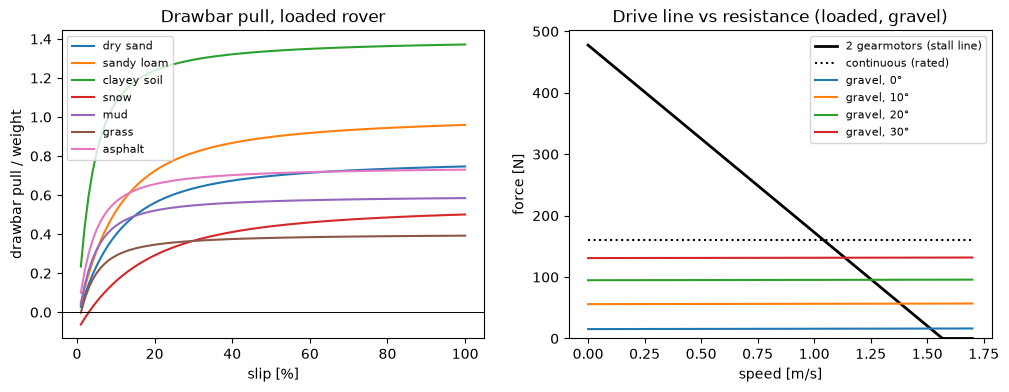

top speed per grade on gravel [m/s]: {'0°': np.float64(1.51), '10°': np.float64(1.38), '20°': np.float64(1.25), '30°': np.float64(1.14)}


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
slip = np.linspace(0.01, 1.0, 100)
for name in ("dry sand", "sandy loam", "clayey soil", "snow", "mud", "grass", "asphalt"):
    s = tm.soil(name)
    dp = 2 * tm.drawbar_pull_track(W / 2, g["b"], g["L"], slip, s) - tracks.internal_coefficient(0.5) * W
    if s.rigid:
        dp = dp - s.c_rr * W
    ax[0].plot(slip * 100, dp / W, label=name)
ax[0].axhline(0, color="k", lw=0.7)
ax[0].set(xlabel="slip [%]", ylabel="drawbar pull / weight", title="Drawbar pull, loaded rover")
ax[0].legend(fontsize=8)
v = np.linspace(0, 1.7, 200)
ax[1].plot(v, drive_force(v), color="k", lw=2, label="2 gearmotors (stall line)")
ax[1].plot(v, 2 * drive.rated_Nm / r_s * np.ones_like(v), color="k", ls=":", label="continuous (rated)")
top = {}
for th in (0, 10, 20, 30):
    R = np.array([tracks.resistance(W, b=g["b"], L=g["L"], soil="gravel", grade_deg=th, v=vv, CdA=CdA)["total"] for vv in v])
    ax[1].plot(v, R, label=f"gravel, {th}°")
    ok = drive_force(v) >= R
    top[f"{th}°"] = v[ok].max() if ok.any() else 0.0
ax[1].set(xlabel="speed [m/s]", ylabel="force [N]", title="Drive line vs resistance (loaded, gravel)", ylim=(0, None))
ax[1].legend(fontsize=8)
fig.savefig(OUT / "drawbar_and_drive.png", dpi=130, bbox_inches="tight")
plt.show()
print("top speed per grade on gravel [m/s]:", {k: round(x, 2) for k, x in top.items()})

In [9]:
# acceleration 0 -> 1.5 m/s on flat gravel: the rover's mass plus the belt's and wheels' rotating inertia
m_belt = sum(v for k, v in budget.items() if k.startswith("track links") or k.startswith("track pins"))
m_eq = cgs["loaded"]["mass_kg"] + m_belt                      # the belt's top run moves at 2v: its kinetic energy ~ +m_belt
t, vv, dt = 0.0, 0.0, 0.002
while vv < 1.45 and t < 10:
    F = float(drive_force(vv)) - tracks.resistance(W, b=g["b"], L=g["L"], soil="gravel", v=vv, CdA=CdA)["total"]
    F = min(F, tracks.tractive_limit(W, b=g["b"], L=g["L"], soil="gravel", slip=0.3))
    vv += F / m_eq * dt
    t += dt
# range and endurance: the electrical power of two DC-motor-estimate gearmotors + 15 W of electronics
E_WH = 240.0 * 0.9                                       # LiFePO4 24 V 10 Ah, 90 % usable
P_ELEC = 15.0
kt, Rw = motor.stall_Nm / motor.stall_A, motor.voltage_V / motor.stall_A
eta_g = gears.chain_efficiency(["planetary stage", "planetary stage"])

def electrical_power(Fx, v):
    """Battery power [W] for a total tractive force Fx [N] at v [m/s]: per motor τ_m = Fx/2 r / (16 η), the
    mechanical power plus the copper loss (τ_m / k_t)² R, plus the electronics."""
    tau_m = Fx / 2 * r_s / (16 * eta_g)
    w_m = v / r_s * 16
    return 2 * (tau_m * w_m + (tau_m / kt) ** 2 * Rw) + P_ELEC

end_rows = {}
for name in ("asphalt", "gravel", "grass", "sandy loam", "dry sand", "snow"):
    for v1 in (0.5, 1.0, 1.5):
        R = tracks.resistance(W, b=g["b"], L=g["L"], soil=name, v=v1, CdA=CdA)["total"]
        P = electrical_power(R, v1)
        end_rows[(name, v1)] = {"resistance [N]": R, "battery power [W]": P, "endurance [h]": E_WH / P,
                                "range [km]": E_WH / P * v1 * 3.6, "cost of transport": P / (W * v1)}
end_tab = pd.DataFrame(end_rows).T
end_tab.index.names = ["ground", "v [m/s]"]
print(f"0 -> 1.45 m/s on flat gravel in {t:.2f} s (loaded, the belt's mass counted twice)")
display(end_tab.style.format("{:.3g}"))

0 -> 1.45 m/s on flat gravel in 0.42 s (loaded, the belt's mass counted twice)


## 4. Stability, steering ratio, road-wheel loads

Static tip-over angles about the ends of the contact patch (fore and aft) and the downhill track's outer edge; the
step the idler climbs (its axle height: the belt wraps it), the trench the tracks bridge. Road-wheel loads: four
wheels on a rigid frame vs two bogies (pairs of wheels pivoting) — the bogies make the split statically determinate.

In [10]:
stab = {}
for lab in ("empty", "loaded"):
    c = cgs[lab]
    stab[lab] = tracks.stability(x_cg=c["x"], z_cg=c["z"], x_front=g["x_front"], x_rear=g["x_rear"],
                                 half_gauge=g["B"] / 2, half_width=g["B"] / 2 + g["b"] / 2, step_height=g["idler"][1],
                                 contact_front=g["L"] / 2, contact_rear=-g["L"] / 2)
stab_tab = pd.DataFrame(stab)
display(stab_tab.style.format("{:.3g}"))
xs = g["wheel_x"]
loads = pd.DataFrame({f"{lab}, {kind}": tracks.road_wheel_loads(cgs[lab]["mass_kg"] * G / 2, xs, cgs[lab]["x"],
                                                                  bogies=None if kind == "rigid" else [(0, 1), (2, 3)])
                      for lab in ("empty", "loaded") for kind in ("rigid", "bogies")},
                     index=[f"wheel {i + 1} (x {x * 1e3:+.0f} mm)" for i, x in enumerate(xs)])
display(loads.style.format("{:.1f}"))
# the grade the bogies see: on a 20° slope the CG's height moves the load downhill by z_cg tan θ
on_slope = {f"{th}° uphill": tracks.road_wheel_loads(W * math.cos(math.radians(th)) / 2, xs,
                                                     cgs["loaded"]["x"] - cgs["loaded"]["z"] * math.tan(math.radians(th)),
                                                     bogies=[(0, 1), (2, 3)]) for th in (0, 10, 20, 30)}
display(pd.DataFrame(on_slope, index=loads.index).style.format("{:.1f}"))

,empty,loaded
tip_uphill_deg,57.1,49.9
tip_downhill_deg,57.1,53.7
tip_side_deg,60.5,55.5
step_m,0.11,0.11
trench_m,0.359,0.345


,"empty, rigid","empty, bogies","loaded, rigid","loaded, bogies"
wheel 1 (x -180 mm),23.3,23.3,33.7,33.0
wheel 2 (x -60 mm),23.3,23.3,30.8,33.0
wheel 3 (x +60 mm),23.3,23.3,28.0,25.8
wheel 4 (x +180 mm),23.3,23.3,25.1,25.8


,0° uphill,10° uphill,20° uphill,30° uphill
wheel 1 (x -180 mm),33.0,39.7,45.2,49.3
wheel 2 (x -60 mm),33.0,39.7,45.2,49.3
wheel 3 (x +60 mm),25.8,18.3,10.1,1.7
wheel 4 (x +180 mm),25.8,18.3,10.1,1.7


## 5. Gears and drive train (5j.2)

The ratio: the gearmotor must reach the top speed on the flat and hold the 30° climb's torque within its
**continuous** rating. A 16:1 two-stage planetary (sun 18, planets 18, ring 54, three planets, module 0.8, 10 mm
faces, 42CrMo4 nitrided) sits in that window. The second stage's sun is the most loaded tooth.

feasible overall ratios: 14.0 … 16.0; chosen 16 = 4 × 4


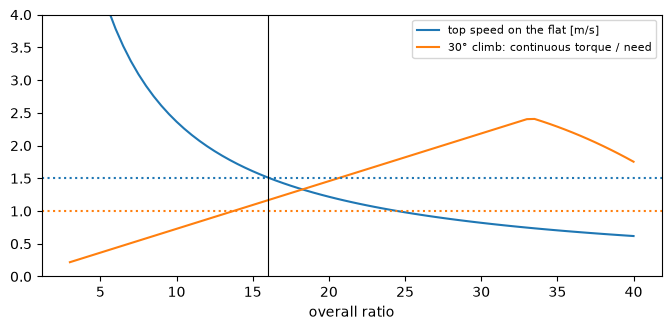

,each stage
z_sun,18
z_planet,18
z_ring,54
n_planets,3
ratio,4.0
assembles,True
neighbours_clear,True


efficiency: 2 planetary stages 0.941, with the sprocket and belt 0.894


In [11]:
climb = tracks.resistance(W, b=g["b"], L=g["L"], soil="gravel", grade_deg=30.0, v=0.5)["total"]
flat = tracks.resistance(W, b=g["b"], L=g["L"], soil="gravel", v=1.5, CdA=CdA)["total"]
eta_all = gears.chain_efficiency(["planetary stage", "planetary stage", "sprocket and belt"])
sel = gears.select_ratio(stall_Nm=motor.stall_Nm, rated_Nm=motor.rated_Nm, no_load_rpm=motor.no_load_rpm,
                         tau_climb=climb / 2 * r_s, omega_climb=0.5 / r_s, tau_flat=flat / 2 * r_s, omega_top=1.5 / r_s,
                         efficiency=eta_all)
ratio_tab = pd.DataFrame(sel["rows"]).set_index("ratio")
print(f"feasible overall ratios: {sel['i_min']} … {sel['i_max']}; chosen 16 = 4 × 4")
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(ratio_tab.index, ratio_tab.top_speed_rad_s * r_s, label="top speed on the flat [m/s]")
ax.plot(ratio_tab.index, ratio_tab.climb_margin, label="30° climb: continuous torque / need")
ax.axhline(1.5, color="C0", ls=":"); ax.axhline(1.0, color="C1", ls=":"); ax.axvline(16, color="k", lw=0.8)
ax.set(xlabel="overall ratio", ylim=(0, 4)); ax.legend(fontsize=8)
fig.savefig(OUT / "ratio.png", dpi=130, bbox_inches="tight")
plt.show()
stage = gears.planetary(18, 54, 3)
display(pd.Series(stage.as_dict(), name="each stage").to_frame())
print(f"efficiency: 2 planetary stages {gears.chain_efficiency(['planetary stage'] * 2):.3f}, with the sprocket and belt {eta_all:.3f}")

In [12]:
MOD, FACE, Z = p["pinion_module"], p["pinion_width"], p["pinion_teeth"]
MAT = gears.MATERIALS["42CrMo4 nitrided"]
gear_rows = {}
for case, Tm in (("rated (continuous)", motor.rated_Nm), ("stall (peak)", motor.stall_Nm)):
    for st, Tin in (("stage 1 sun", Tm), ("stage 2 sun", Tm * 4 * gears.MESH_EFFICIENCY["planetary stage"])):
        Ft = gears.stage_loads(Tin, MOD, Z, 3)["Ft_N"]
        sF = gears.lewis_bending(Ft, MOD, FACE, Z)
        sH = gears.contact_stress(Ft, MOD * Z, FACE, 1.0)
        sH_ring = gears.contact_stress(Ft, MOD * Z, FACE, 3.0, internal=True)
        gear_rows[(case, st)] = {"T_sun [N·m]": Tin, "F_t per mesh [N]": Ft, "σ_F Lewis [MPa]": sF,
                                 "SF bending": MAT.sigma_F_lim / sF, "σ_H sun–planet [MPa]": sH,
                                 "SF contact": MAT.sigma_H_lim / sH, "σ_H planet–ring [MPa]": sH_ring}
gear_tab = pd.DataFrame(gear_rows).T
display(gear_tab.style.format("{:.3g}"))

,load [N],max von Mises [MPa],SF yield,Lewis σ_F [MPa],deflection [mm]
"pinion, stall mesh force",196.24537,82.353312,10.928522,79.387286,0.001494


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:155: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.25, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


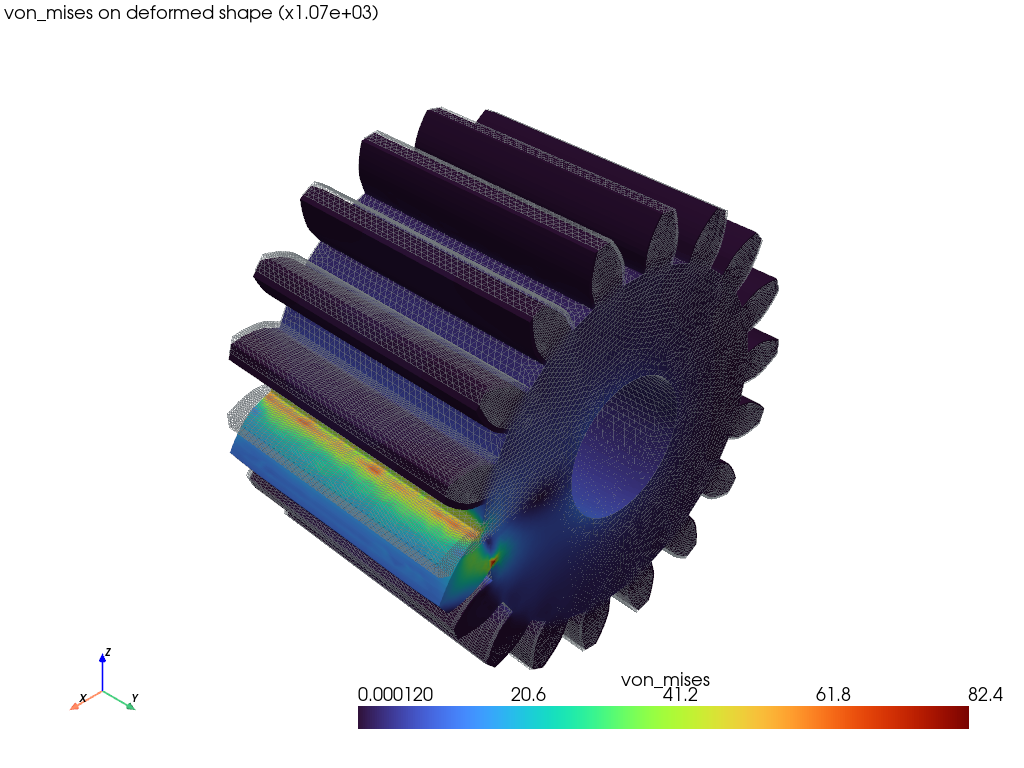

In [13]:
# Talos FEA on the stage-2 sun pinion: the bore fixed (keyed shaft), one tooth flank loaded with the stall mesh
# force (tangential + radial at 20°) — the root fillet's stress against the Lewis value (Lewis has no notch factor)
r_p = MOD * Z / 2
ra = r_p + MOD
Ft_stall = gear_rows[("stall (peak)", "stage 2 sun")]["F_t per mesh [N]"]
STEEL = talos.Material("42CrMo4 nitrided (core QT)", youngs_modulus=210000.0, poissons_ratio=0.30, density=7.85e-9,
                       yield_strength=900.0, source="handbook: 42CrMo4 QT core, nitrided case not modelled")
pin_model = talos.StructuralModel(cad["pinion"].artifacts["step"], "mm-N-MPa", STEEL,
                                  [talos.SurfacesInBox("bore", (-2.6, -6, -2.6, 2.6, 6, 2.6)),
                                   talos.SurfacesInBox("flank", (6.6, -6, 0.05, ra + 0.1, 6, 1.3))],
                                  [talos.FixedSupport("bore")],
                                  [talos.Force("flank", fx=-Ft_stall * math.tan(math.radians(20)), fz=-Ft_stall)],
                                  talos.MeshSettings(element_size=0.5, min_element_size=0.25), name="pinion_stall")
pin_model.mesh(RUNS / "pinion_fea", progress=True)
pin_res = pin_model.solve(RUNS / "pinion_fea", progress=True)
fea_rows = {"pinion, stall mesh force": {"load [N]": Ft_stall, "max von Mises [MPa]": pin_res.metrics.get("max_von_mises"),
                                         "SF yield": pin_res.metrics.get("safety_factor_yield"),
                                         "Lewis σ_F [MPa]": gear_rows[("stall (peak)", "stage 2 sun")]["σ_F Lewis [MPa]"],
                                         "deflection [mm]": pin_res.metrics.get("max_displacement")}}
display(pd.DataFrame(fea_rows).T)
tviz.show(tviz.plot_results(pin_res, field="von_mises"))

,duration [s],speed [m/s],force per track [N],sprocket torque [N·m]
"gravel, 1.5 m/s",600,1.5,8.09,0.484
grass up 15°,120,0.8,41.5,2.48
grass down 15°,120,0.8,-19.5,-1.16
"dry sand, 0.8 m/s",300,0.8,4.84,0.29
sandy loam up 20°,120,0.6,44.3,2.65
gravel turns R 1 m,300,0.5,31.6,1.89
"asphalt, 1.5 m/s",840,1.5,6.32,0.379


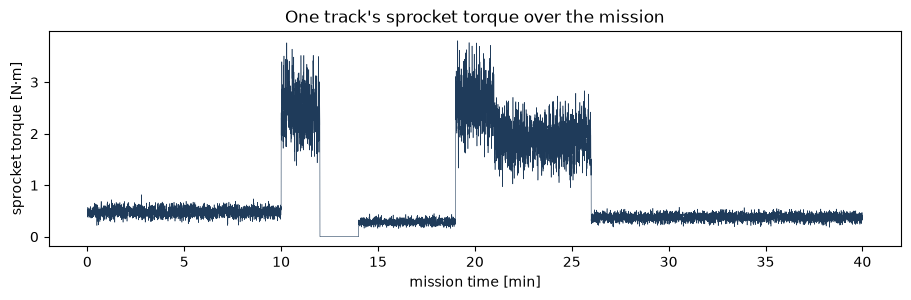

In [14]:
# a mission: 40 min of patrol with the 5 kg payload — gravel, grass slopes, sand, skid turns — as a sprocket force
# history (resistance + the steering forces of the outer track, plus ground roughness as ±15 % noise)
rng = np.random.default_rng(1)
SEGMENTS = [("gravel, 1.5 m/s", "gravel", 0.0, 1.5, 600), ("grass up 15°", "grass", 15.0, 0.8, 120),
            ("grass down 15°", "grass", -15.0, 0.8, 120), ("dry sand, 0.8 m/s", "dry sand", 0.0, 0.8, 300),
            ("sandy loam up 20°", "sandy loam", 20.0, 0.6, 120), ("gravel turns R 1 m", "gravel", 0.0, 0.5, 300),
            ("asphalt, 1.5 m/s", "asphalt", 0.0, 1.5, 840)]
DT = 0.05
F_hist, v_hist, seg_rows = [], [], {}
for name, soil, th, v1, T in SEGMENTS:
    R = tracks.resistance(W, b=g["b"], L=g["L"], soil=soil, grade_deg=th, v=v1, CdA=CdA)["total"]
    if "turns" in name:
        tr = tracks.skid_steer(W, L=g["L"], B=g["B"], R=1.0, mu_t_max=0.5, rolling=R, v=v1)
        F_side = tr["F_outer_N"]
    else:
        F_side = R / 2
    n = int(T / DT)
    sm = np.convolve(rng.normal(0, 1, n), np.ones(10) / 10, mode="same") * 0.15 / 0.32
    F = np.clip(F_side * (1 + sm), 0, None)
    F_hist.append(F); v_hist.append(np.full(n, v1))
    seg_rows[name] = {"duration [s]": T, "speed [m/s]": v1, "force per track [N]": F_side,
                      "sprocket torque [N·m]": F_side * r_s}
F_hist, v_hist = np.concatenate(F_hist), np.concatenate(v_hist)
MISSION_S = len(F_hist) * DT
display(pd.DataFrame(seg_rows).T.style.format("{:.3g}"))
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(np.arange(len(F_hist)) * DT / 60, F_hist * r_s, lw=0.4, color="#1f3b5a")
ax.set(xlabel="mission time [min]", ylabel="sprocket torque [N·m]", title="One track's sprocket torque over the mission")
fig.savefig(OUT / "mission_torque.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
# tooth life: every load level is a pulsating tooth-root stress (0 -> σ) once per mesh. The stage-2 carrier is the
# output (the sprocket); its sun turns at 4x, i.e. 3x relative to the carrier, and each sun tooth meets 3 planets per
# relative turn -> 9 load cycles per sprocket turn, counted per load level (load-duration bins) and summed with
# Miner (Chronos hotspot_damage)
T_spr = F_hist * r_s
w_spr = v_hist / r_s
sun2_rel_turns = w_spr * DT / (2 * math.pi) * 3                # stage-2 sun relative to its carrier
cycles = sun2_rel_turns * 3                                     # 3 planets
bins = np.linspace(0, T_spr.max() * 1.001, 25)
idx = np.digitize(T_spr, bins)
per_N = gear_rows[("rated (continuous)", "stage 2 sun")]["σ_F Lewis [MPa]"] / (motor.rated_Nm * 4 * gears.MESH_EFFICIENCY["planetary stage"])  # MPa per N·m on the stage-2 sun
sun_per_spr = 1 / (4 * gears.MESH_EFFICIENCY["planetary stage"] * gears.MESH_EFFICIENCY["sprocket and belt"])   # N·m on the sun per N·m at the sprocket
blocks_F, blocks_H = [], []
for k in range(1, len(bins)):
    sel_k = idx == k
    if not sel_k.any():
        continue
    Tk = bins[k]
    n = float(cycles[sel_k].sum())
    blocks_F.append(chronos.Block("tooth_root", Tk / 2, Tk / 2, n, f"sprocket torque ≤ {Tk:.2f} N·m"))
    blocks_H.append(chronos.Block("contact", 0.0, Tk, n, f"sprocket torque ≤ {Tk:.2f} N·m"))
spec_F = chronos.LoadSpectrum("pekari patrol", MISSION_S, blocks_F, ["tooth_root"], notes="load levels x mesh cycles")
spec_H = chronos.LoadSpectrum("pekari patrol", MISSION_S, blocks_H, ["contact"], notes="load levels x mesh cycles")
sF_per_Nm = per_N * sun_per_spr
# σ_H grows with √T: use the linearised value at the bin's torque (the curve below takes the exact √ instead)
Ft1 = gears.stage_loads(1.0, MOD, Z, 3)["Ft_N"]
CURVE_F = chronos.SNCurve("42CrMo4 nitrided tooth root (pulsating, amplitude)", sigma_f=MAT.sigma_F_lim / 2 * (2 * 3e6) ** (-MAT.b_F),
                          b=MAT.b_F, endurance_limit=MAT.sigma_F_lim / 2)
dmg_F = chronos.hotspot_damage(spec_F, {"tooth_root": sF_per_Nm}, CURVE_F)
dmg_H = 0.0
for b in blocks_H:
    sH = gears.contact_stress(Ft1 * b.amplitude * sun_per_spr, MOD * Z, FACE, 1.0) if b.amplitude > 0 else 0.0
    N = gears.sn_cycles(sH, MAT.sigma_H_lim, 5e7, MAT.b_H)
    dmg_H += b.cycles / N if math.isfinite(N) else 0.0
life = pd.Series({"mission [min]": MISSION_S / 60, "sun-2 tooth cycles per mission": cycles.sum(),
                  "root damage per mission": dmg_F["total"], "contact damage per mission": dmg_H,
                  "root life [h]": MISSION_S / 3600 / dmg_F["total"] if dmg_F["total"] > 0 else math.inf,
                  "contact life [h]": MISSION_S / 3600 / dmg_H if dmg_H > 0 else math.inf}, name="stage-2 sun")
display(life.to_frame())

,stage-2 sun
mission [min],4.000000e+01
sun-2 tooth cycles per mission,6.730561e+04
root damage per mission,0.000000e+00
contact damage per mission,0.000000e+00
root life [h],inf
contact life [h],inf


In [16]:
# the output shaft (12 mm, 42CrMo4): torsion from the torque history, rainflow-counted (the torque's own swings)
d_shaft = p["sprocket_bore"]
tau_per_Nm = 16 * 1000 / (math.pi * d_shaft ** 3)               # MPa per N·m
rf = chronos.rainflow(T_spr[::2])
blocks = [chronos.Block("shaft_torsion", m, rng_ / 2, c, "rainflow") for rng_, m, c in rf if rng_ > 0]
spec_shaft = chronos.LoadSpectrum("pekari patrol", MISSION_S, blocks, ["shaft_torsion"])
CURVE_SHAFT = chronos.SNCurve("42CrMo4 QT, torsion (von Mises-scaled)", sigma_f=1100 / math.sqrt(3), b=-0.085,
                              ultimate=1000 / math.sqrt(3), endurance_limit=250 / math.sqrt(3))
dmg_shaft = chronos.hotspot_damage(spec_shaft, {"shaft_torsion": tau_per_Nm}, CURVE_SHAFT)
print(f"shaft: max torsion {T_spr.max() * tau_per_Nm:.1f} MPa, {spec_shaft.total_cycles:.0f} rainflow cycles per "
      f"mission, damage {dmg_shaft['total']:.2e} (below the endurance limit = 0)")
chord = gears.sprocket_chordal(g["z_teeth"], p["track_pitch"])
f_poly = 1.5 / (2 * math.pi * r_s) * g["z_teeth"]
print(f"sprocket polygon effect: belt speed varies by {chord['speed_variation'] * 100:.1f} % at {f_poly:.1f} Hz "
      f"(1.5 m/s) — {g['z_teeth']} teeth; 20 teeth would give {gears.sprocket_chordal(20, 31.0)['speed_variation'] * 100:.1f} %")
print(f"a friction-driven rubber band (no teeth) on this sprocket: wrap ≈ 150°, μ 0.5 -> tight/slack ≤ "
      f"{gears.capstan(0.5, math.radians(150)):.2f}: the slack side would need ≥ {1 / (gears.capstan(0.5, math.radians(150)) - 1):.2f}× the drive force")

shaft: max torsion 11.2 MPa, 5740 rainflow cycles per mission, damage 0.00e+00 (below the endurance limit = 0)
sprocket polygon effect: belt speed varies by 3.4 % at 47.8 Hz (1.5 m/s) — 12 teeth; 20 teeth would give 1.2 %
a friction-driven rubber band (no teeth) on this sprocket: wrap ≈ 150°, μ 0.5 -> tight/slack ≤ 3.70: the slack side would need ≥ 0.37× the drive force


## 6. The track (5j.3)

**Which track.** A rubber band (moulded steel cords, rubber lugs) is light, quiet and gentle on floors but needs a
large wrap and pre-tension and is thrown more easily; hinged links (here PA6-GF30 with steel pins) are positively
driven by the sprocket, repairable link by link and stiffer sideways, but heavier and noisier. A *dead* track (plain
pins, as here) needs the tensioner to take up wear; a *live* track (rubber-bushed pins) springs back to shape and
loses less on the hinges.

In [17]:
track_types = pd.DataFrame({
    "rubber band": {"mass per metre": "~1.0 kg/m (estimate, 80 mm)", "drive": "friction or moulded lugs", "throw risk": "higher",
                    "wear": "lugs, band cracking", "noise / floors": "quiet, no marks", "repair": "replace the band"},
    "hinged links, dead (this design)": {"mass per metre": f"{(m_belt / 2) / g['belt_length']:.2f} kg/m", "drive": "positive, sprocket on the knuckles",
                                         "throw risk": "lower (guide horns)", "wear": "pins and bores: take up on the idler",
                                         "noise / floors": "noisy, marks", "repair": "one link"},
    "hinged links, live": {"mass per metre": "+10-20 %", "drive": "positive", "throw risk": "lower",
                           "wear": "bushings age", "noise / floors": "quieter", "repair": "one link"}}).T
display(track_types)
suspension = pd.DataFrame({
    "rigid wheels": {"load sharing on bumps": "poor (one wheel can carry a side)", "parts": "fewest", "fits this size": "yes"},
    "bogies (this design)": {"load sharing on bumps": "pairs share, statically determinate", "parts": "+2 pivots per side", "fits this size": "yes"},
    "torsion bars / trailing arms": {"load sharing on bumps": "each wheel sprung", "parts": "+1 arm, bar per wheel", "fits this size": "tight at 70 mm wheels"},
    "Christie / Horstmann": {"load sharing on bumps": "long travel, high speed", "parts": "springs per wheel/pair", "fits this size": "overkill at 1.5 m/s"}}).T
display(suspension)

,mass per metre,drive,throw risk,wear,noise / floors,repair
rubber band,"~1.0 kg/m (estimate, 80 mm)",friction or moulded lugs,higher,"lugs, band cracking","quiet, no marks",replace the band
"hinged links, dead (this design)",1.55 kg/m,"positive, sprocket on the knuckles",lower (guide horns),pins and bores: take up on the idler,"noisy, marks",one link
"hinged links, live",+10-20 %,positive,lower,bushings age,quieter,one link


,load sharing on bumps,parts,fits this size
rigid wheels,poor (one wheel can carry a side),fewest,yes
bogies (this design),"pairs share, statically determinate",+2 pivots per side,yes
torsion bars / trailing arms,each wheel sprung,"+1 arm, bar per wheel",tight at 70 mm wheels
Christie / Horstmann,"long travel, high speed",springs per wheel/pair,overkill at 1.5 m/s


In [18]:
# tension: the top run's sag between the return roller and the sprocket/idler, the tension that keeps the guide
# horns engaged in a pivot turn, and the tight-side force at the drive's limit
w_belt = (m_belt / 2) / g["belt_length"] * G                       # N/m
spans = {"sprocket – return roller": abs(g["sprocket"][0]), "return roller – idler": abs(g["idler"][0])}
mu_t_max = 0.5
F_lat = mu_t_max * (W / 2) * (p["road_wheel_spacing"] / 1000) / g["L"]   # the lateral ground force on one wheel span
T_derail = tracks.derail_tension(F_lat, p["road_wheel_spacing"] / 1000, g["guide_height"])
T0 = max(60.0, T_derail)
F_drive_max = min(drive.stall_Nm / r_s, tm.max_thrust_track(W / 2, g["b"], g["L"], "asphalt"))
dt_ = tracks.drive_tension(T0, F_drive_max)
tension = pd.Series({"belt weight [N/m]": w_belt, **{f"sag, {k} [mm]": tracks.sag(T0, w_belt, s) * 1e3 for k, s in spans.items()},
                     "lateral force per wheel span in a pivot turn [N]": F_lat, "tension against derailing [N]": T_derail,
                     "pre-tension chosen T0 [N]": T0, "drive force limit per track [N]": F_drive_max,
                     "tight side [N]": dt_["tight"], "slack side [N]": dt_["slack"]}, name="per track")
display(tension.to_frame().style.format("{:.3g}"))
# the pin by hand (as notebook 11): double shear through the knuckles, bending over the knuckle width
def pin_bending(F, lever_mm, d_mm):
    return F * lever_mm / (math.pi * d_mm ** 3 / 32)
def pin_shear(F, d_mm, n=2):
    return F / (n * math.pi * d_mm ** 2 / 4)
T_t = dt_["tight"]
sb, ts = pin_bending(T_t / 2, p["track_width"] / 8, p["pin_diameter"]), pin_shear(T_t, p["pin_diameter"])
bear = T_t / (p["pin_diameter"] * p["track_width"] / 2)            # bearing pressure in the PA6 bores
pins = pd.Series({"bending [MPa]": sb, "shear [MPa]": ts, "von Mises [MPa]": math.hypot(sb, math.sqrt(3) * ts),
                  "SF to yield (42CrMo4 QT, 700 MPa)": 700 / math.hypot(sb, math.sqrt(3) * ts),
                  "bearing pressure in the PA6 bores [MPa]": bear}, name="pin at the tight-side limit")
display(pins.to_frame().style.format("{:.3g}"))

,per track
belt weight [N/m],15.2
"sag, sprocket – return roller [mm]",1.94
"sag, return roller – idler [mm]",1.94
lateral force per wheel span in a pivot turn [N],16.4
tension against derailing [N],82.1
pre-tension chosen T0 [N],82.1
drive force limit per track [N],91.9
tight side [N],174
slack side [N],82.1


,pin at the tight-side limit
bending [MPa],70.9
shear [MPa],4.43
von Mises [MPa],71.3
"SF to yield (42CrMo4 QT, 700 MPa)",9.81
bearing pressure in the PA6 bores [MPa],0.87


,load [N],max von Mises [MPa],SF yield,Lewis σ_F [MPa],deflection [mm]
"pinion, stall mesh force",196.245370,82.353312,10.928522,79.387286,0.001494
"link, tight side",174.047374,6.339138,15.775015,NaN,0.022900
"sprocket, drive limit on one seat pair",91.949556,1.214078,82.367046,NaN,0.013510


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:155: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.25, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


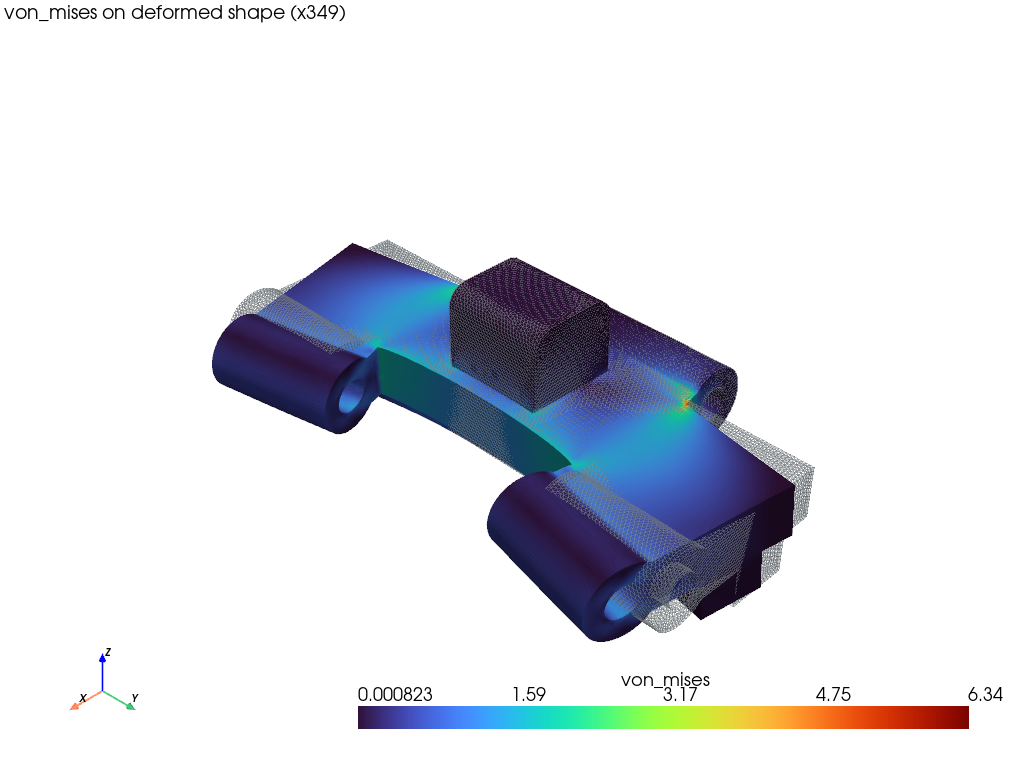

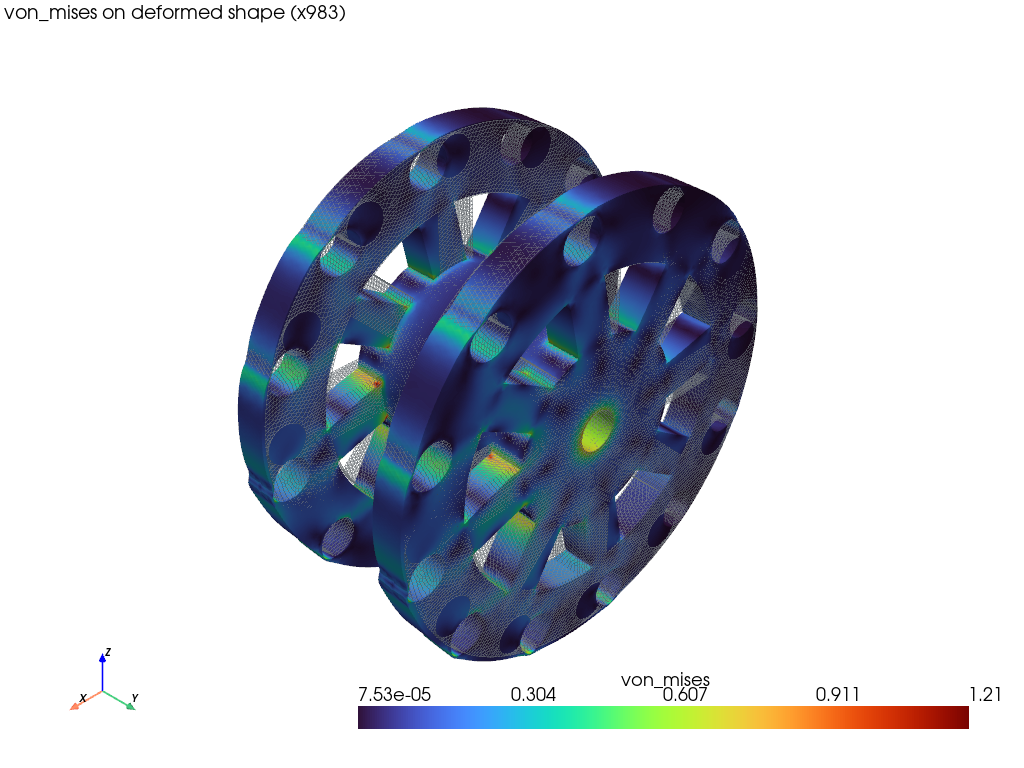

In [19]:
# Talos FEA: one link pulled by the tight-side force (rear pin bore fixed, front pin bore loaded), and the sprocket
# with that force on one pair of tooth seats (bore fixed) — both PA6-GF30, conditioned
PA6GF = talos.Material("PA6-GF30 (conditioned)", youngs_modulus=6000.0, poissons_ratio=0.35, density=1.36e-9,
                       yield_strength=100.0, source="datasheet class, 50 % RH; dry: 9500 MPa / 160 MPa")
P_ = p["track_pitch"]
link_model = talos.StructuralModel(cad["track_link"].artifacts["step"], "mm-N-MPa", PA6GF,
                                   [talos.SurfacesInBox("rear_pin", (-P_ / 2 - 2.6, -50, -2.6, -P_ / 2 + 2.6, 50, 2.6)),
                                    talos.SurfacesInBox("front_pin", (P_ / 2 - 2.6, -50, -2.6, P_ / 2 + 2.6, 50, 2.6))],
                                   [talos.FixedSupport("rear_pin")], [talos.Force("front_pin", fx=T_t)],
                                   talos.MeshSettings(element_size=1.2, min_element_size=0.4), name="link_tight")
R_mm = r_s * 1000
spr_model = talos.StructuralModel(cad["sprocket"].artifacts["step"], "mm-N-MPa", PA6GF,
                                  [talos.SurfacesInBox("bore", (-6.1, -50, -6.1, 6.1, 50, 6.1)),
                                   talos.SurfacesInBox("seat", (R_mm - 6.6, -50, -6.6, R_mm + 7.0, 50, 6.6))],
                                  [talos.FixedSupport("bore")], [talos.Force("seat", fz=-F_drive_max)],
                                  talos.MeshSettings(element_size=2.5, min_element_size=0.8), name="sprocket_drive")
results = {}
for name, model, d in tqdm([("link", link_model, "link_fea"), ("sprocket", spr_model, "sprocket_fea")],
                           desc="FEA: link, sprocket"):
    model.mesh(RUNS / d, progress=True)
    results[name] = model.solve(RUNS / d, progress=True)
link_res, spr_res = results["link"], results["sprocket"]
for name, res, load in (("link, tight side", link_res, T_t), ("sprocket, drive limit on one seat pair", spr_res, F_drive_max)):
    fea_rows[name] = {"load [N]": load, "max von Mises [MPa]": res.metrics.get("max_von_mises"),
                      "SF yield": res.metrics.get("safety_factor_yield"), "deflection [mm]": res.metrics.get("max_displacement")}
fea_tab = pd.DataFrame(fea_rows).T
display(fea_tab)
tviz.show(tviz.plot_results(link_res, field="von_mises"))
tviz.show(tviz.plot_results(spr_res, field="von_mises"))

In [20]:
# link fatigue: each link sees one tension cycle per lap (slack T0 -> tight T0 + F), F from the mission history;
# PA6-GF30 S-N (assumed, conditioned, R ≈ 0.1: ~31 MPa amplitude at 10⁷) with Goodman on the mean
laps = v_hist * DT / g["belt_length"]
link_per_N = (link_res.metrics.get("max_von_mises") or 0.0) / T_t
Fb = np.linspace(0, F_hist.max() * 1.001, 25)
ib = np.digitize(F_hist, Fb)
blocks_L = [chronos.Block("link_tension", T0 + Fb[k] / 2, Fb[k] / 2, float(laps[ib == k].sum()), "per lap")
            for k in range(1, len(Fb)) if (ib == k).any()]
spec_L = chronos.LoadSpectrum("pekari patrol", MISSION_S, blocks_L, ["link_tension"])
CURVE_PA = chronos.SNCurve("PA6-GF30 conditioned (assumed)", sigma_f=120.0, b=-0.08, ultimate=100.0)
dmg_L = chronos.hotspot_damage(spec_L, {"link_tension": link_per_N}, CURVE_PA)
km_per_mission = float((v_hist * DT).sum() / 1000)
# hinge wear (Archard): every lap each hinge swings in and out of the wraps, ~2 x 2π of rotation, sliding r_pin per rad
K_WEAR = {"clean": 2e-6, "sandy (abrasive)": 2e-4}               # mm³/(N·m), PA6-GF30 on steel (assumed)
slide_per_km = 1000 / g["belt_length"] * 4 * math.pi * (p["pin_diameter"] / 2000)
p_mean = (T0 + F_hist.mean()) / (p["pin_diameter"] * p["track_width"] / 2)   # MPa in the bores
wear_per_km = {k: kw * p_mean * slide_per_km for k, kw in K_WEAR.items()}   # mm of bore per km (Archard h = k p s)
life_link = pd.Series({"km per mission": km_per_mission, "laps per mission": laps.sum(),
                       "link damage per mission": dmg_L["total"],
                       "link fatigue life [km]": km_per_mission / dmg_L["total"] if dmg_L["total"] > 0 else math.inf,
                       "hinge sliding per km [m]": slide_per_km, "mean bore pressure [MPa]": p_mean,
                       **{f"bore wear per km, {k} [mm]": w for k, w in wear_per_km.items()},
                       **{f"km until the idler's take-up is used, {k}": (g["take_up"] * 1e3 / 2 + p["track_pitch"] / 2) * 2 / (g["links"] * w)
                          for k, w in wear_per_km.items()}},
                      name="track belt")
display(life_link.to_frame().style.format("{:.3g}"))

,track belt
km per mission,2.81
laps per mission,1.8e+03
link damage per mission,8.15e-25
link fatigue life [km],3.45e+24
hinge sliding per km [m],20.1
mean bore pressure [MPa],0.476
"bore wear per km, clean [mm]",1.91e-05
"bore wear per km, sandy (abrasive) [mm]",0.00191
"km until the idler's take-up is used, clean",5.18e+04
"km until the idler's take-up is used, sandy (abrasive)",518


### Skid steering

A tracked vehicle turns by driving its tracks at different speeds; the ground resists with a moment
M_r = μ_t W L / 4. The outer track pushes R/2 + M_r/B, the inner one R/2 − M_r/B — negative means it must brake.
A clutch-brake steer burns the inner track's braking power; a regenerative (differential or electric) steer passes
it to the outer track — here two independent motors can regenerate if their controllers allow it.

,"μ_t,max (assumed)",pivot turn M_r [N·m],pivot: outer track [N],track force limit [N],pivot turn possible,min radius [m],"R 1 m, 0.5 m/s: clutch-brake [W]",R 1 m: regenerative [W],R 1 m: braked power lost [W]
asphalt,0.6,16.410688,45.833118,91.949556,True,0.0,20.853745,11.889237,8.964508
gravel,0.5,13.675573,40.959593,68.962167,True,0.0,19.045614,12.673026,6.372588
grass,0.45,12.308016,41.170485,57.468473,True,0.0,19.738084,15.712575,4.025509
dry sand,0.4,10.940459,31.294959,92.626449,True,0.0,14.348443,8.665705,5.682738


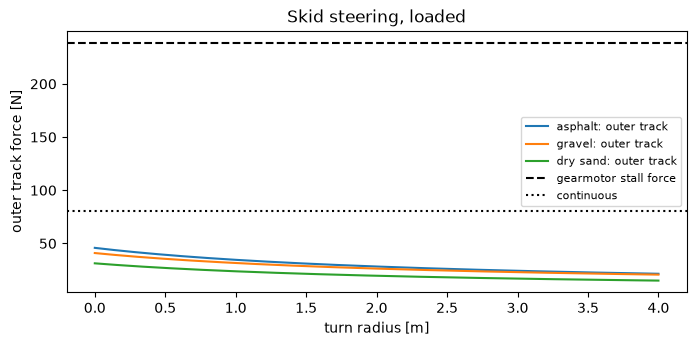

In [21]:
steer = {}
for soil, mu_t in (("asphalt", 0.6), ("gravel", 0.5), ("grass", 0.45), ("dry sand", 0.4)):
    Rr = tracks.resistance(W, b=g["b"], L=g["L"], soil=soil, v=0.5)["total"]
    Fmax = min(drive.stall_Nm / r_s, tm.max_thrust_track(W / 2, g["b"], g["L"], soil))
    pivot = tracks.skid_steer(W, L=g["L"], B=g["B"], R=0.0, mu_t_max=mu_t, rolling=Rr)
    r1 = tracks.skid_steer(W, L=g["L"], B=g["B"], R=1.0, mu_t_max=mu_t, rolling=Rr, v=0.5)
    steer[soil] = {"μ_t,max (assumed)": mu_t, "pivot turn M_r [N·m]": pivot["M_r_Nm"], "pivot: outer track [N]": pivot["F_outer_N"],
                   "track force limit [N]": Fmax, "pivot turn possible": pivot["F_outer_N"] <= Fmax,
                   "min radius [m]": tracks.min_turn_radius(W, L=g["L"], B=g["B"], mu_t_max=mu_t, rolling=Rr, F_max=Fmax),
                   "R 1 m, 0.5 m/s: clutch-brake [W]": r1["P_clutch_brake_W"], "R 1 m: regenerative [W]": r1["P_regenerative_W"],
                   "R 1 m: braked power lost [W]": r1["P_braked_lost_W"]}
steer_tab = pd.DataFrame(steer).T
display(steer_tab)
fig, ax = plt.subplots(figsize=(8, 3.4))
Rg = np.linspace(0, 4, 200)
for soil, mu_t in (("asphalt", 0.6), ("gravel", 0.5), ("dry sand", 0.4)):
    Rr = tracks.resistance(W, b=g["b"], L=g["L"], soil=soil, v=0.5)["total"]
    ax.plot(Rg, [tracks.skid_steer(W, L=g["L"], B=g["B"], R=x, mu_t_max=mu_t, rolling=Rr)["F_outer_N"] for x in Rg], label=f"{soil}: outer track")
ax.axhline(drive.stall_Nm / r_s, color="k", ls="--", label="gearmotor stall force")
ax.axhline(drive.rated_Nm / r_s, color="k", ls=":", label="continuous")
ax.set(xlabel="turn radius [m]", ylabel="outer track force [N]", title="Skid steering, loaded")
ax.legend(fontsize=8)
fig.savefig(OUT / "skid_steer.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. MuJoCo: a short run and a turn on uneven ground

The rover in MuJoCo through Chiron (`pekari_rover_robot.pekari()`), loaded with 5 kg in the basket. MuJoCo has no
track, so each track is a row of rollers under the belt's outer surface:
- the raised sprocket and idler;
- the four road wheels and a belt roller between each pair (one every 60 mm);
- a roller on each inclined run, so that an obstacle meets a ramp as it would on the real belt.

The road wheels ride on the two bogies (passive hinges, ±12°). Every roller is a velocity servo at the side's belt
speed, the track's internal loss is the rollers' friction, and the ground is rigid with μ = 0.6 (gravel). The
controller (`pekari_controller.TrackDrive`) runs the mission: 3 m straight at 0.8 m/s, a 90° left turn on a 1 m radius
at 0.5 m/s, then 2 m straight. The ground is rough soil (RMS 15 mm) with a 60 mm log across the path and three 40 mm
stones.

In [ ]:
from vegeta import chiron
from vegeta.chiron import viz as cviz
import pekari_controller as pc

robot = prr.pekari()
print(f"{robot.name}: {robot.total_mass():.2f} kg (budget, loaded: {cgs['loaded']['mass_kg']:.2f} kg), "
      f"{len(robot.links())} links, {len(robot.joints())} joints ({len(robot.actuated_joints())} rollers driven), "
      f"{len(robot.feet)} rollers as feet")
# standing on flat ground: what each roller carries
lab_flat = prr.pekari_lab(chiron.Flat(), robot=robot)
ep_stand = pc.run(lab_flat, legs=[], duration=1.0)
fz = np.asarray(ep_stand.log["foot_force"])[-1, :, 2]
stand = pd.DataFrame({"x [mm]": [x * 1e3 for _, x, *_ in robot.rollers] * 2,
                      "load [N]": fz}, index=list(ep_stand.log["feet"]))
display(stand.T.round(1))
print(f"sum of the roller loads {fz.sum():.1f} N vs the weight {robot.total_mass() * G:.1f} N; "
      f"hull tilt {pc.timeseries(ep_stand).tilt_deg.iloc[-1]:.2f}°")

In [ ]:
ground = pc.uneven_ground()
lab = prr.pekari_lab(ground, robot=robot, log_geoms=True)
ep = pc.run(lab, pc.MISSION, duration=16.0)
ep.save(RUNS / "pekari_terrain_turn.npz")
print(ground)
for t_ev, kind, detail in ep.log["events"]:
    print(f"  t = {t_ev:5.2f} s  {kind}: {detail}")
ts = pc.timeseries(ep)
leg_tab = pc.leg_table(ep)
display(leg_tab.style.format("{:.3g}"))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
xg, yg = np.meshgrid(np.linspace(-0.5, 5.5, 301), np.linspace(-1.0, 4.5, 276))
cs = ax[0].contourf(xg, yg, ground.height(xg, yg) * 1000, levels=24, cmap="terrain")
fig.colorbar(cs, ax=ax[0], label="ground height [mm]")
ax[0].plot(ts.x, ts.y, color="k", lw=1.5, label="COM path")
ax[0].set(aspect="equal", xlabel="x [m]", ylabel="y [m]", title="Path over the ground")
ax[1].plot(ts.t, ts.v, label="ground speed [m/s]")
ax[1].plot(ts.t, ts.yaw_deg / 100, label="heading [deg / 100]")
ax[1].plot(ts.t, ts.tilt_deg / 10, label="tilt [deg / 10]")
for t_ev, kind, _ in ep.log["events"]:
    ax[1].axvline(t_ev, color="#999", lw=0.8, ls=":")
ax[1].set(xlabel="t [s]", title="Speed, heading, tilt"); ax[1].legend(fontsize=8)
ax[2].plot(ts.t, ts.F_L, label="left belt force")
ax[2].plot(ts.t, ts.F_R, label="right belt force")
ax[2].axhline(drive.stall_Nm / r_s, color="k", ls="--", label="gearmotor stall force")
ax[2].axhline(-drive.stall_Nm / r_s, color="k", ls="--")
ax[2].set(xlabel="t [s]", ylabel="N", title="Side forces (Σ roller torque / radius)"); ax[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "mujoco_terrain_turn.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# the run against the hand numbers: the straight legs' mean side force vs tracks.resistance on gravel (no soil in
# MuJoCo: rigid ground; the internal loss is in the rollers), the turn's outer/inner forces vs Wong's skid steering
# with μ_t = the rollers' μ — the rollers' line contacts and the rough ground make the simulation differ
W_sim = robot.total_mass() * G
R_flat = tracks.resistance(W_sim, b=g["b"], L=g["L"], soil="gravel", v=0.8)
R_int = R_flat["internal"]                      # the rollers carry this loss; MuJoCo adds the climbing over the bumps
turn = tracks.skid_steer(W_sim, L=g["L"], B=g["B"], R=1.0, mu_t_max=0.6, rolling=R_int, v=0.5)
legs = list(leg_tab.index)
cmp_tab = pd.DataFrame({
    "straight 3 m: per side": {"MuJoCo [N]": leg_tab.loc[legs[0], ["F_L mean [N]", "F_R mean [N]"]].mean(),
                               "hand [N]": R_int / 2},
    "turn: outer (right) track": {"MuJoCo [N]": leg_tab.loc[legs[1], "F_R mean [N]"], "hand [N]": turn["F_outer_N"]},
    "turn: inner (left) track": {"MuJoCo [N]": leg_tab.loc[legs[1], "F_L mean [N]"], "hand [N]": turn["F_inner_N"]}}).T
display(cmp_tab.style.format("{:.1f}"))

In [ ]:
dt_log = float(ep.log["t"][1] - ep.log["t"][0]); every = max(1, int(round(1 / (25 * dt_log))))
imgs = cviz.frames(ep, camera="follow", every=every, size=(960, 540))
movie = cviz.to_video(imgs, OUT / "pekari_terrain_turn.mp4", fps=25)
print(f"movie: {movie} ({len(imgs)} frames)")
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax_, j in zip(axes, np.linspace(0, len(imgs) - 1, 4).astype(int)):
    ax_.imshow(imgs[j]); ax_.set_axis_off(); ax_.set_title(f"t = {j * every * dt_log:.1f} s", fontsize=9)
fig.tight_layout()
plt.show()

## 8. Export

In [22]:
for name, df in (("mass_budget", budget.to_frame()), ("soil", soil_tab), ("resistance", res_tab), ("endurance", end_tab),
                 ("stability", stab_tab), ("road_wheel_loads", loads), ("gears", gear_tab), ("fea", fea_tab),
                 ("skid_steer", steer_tab), ("mujoco_legs", leg_tab), ("mujoco_vs_hand", cmp_tab)):
    df.to_csv(OUT / f"{name}.csv")
summary_doc = {"source": "30_pekari_rover", "design": {"file": "designs/pekari_rover.py", "parameters": p},
               "mass_kg": {"empty": cgs["empty"]["mass_kg"], "loaded": cgs["loaded"]["mass_kg"]},
               "ground_pressure_kPa": p_nom / 1e3, "mmp_kPa": mmp / 1e3,
               "max_grade_deg": res_tab["max grade loaded [deg]"].to_dict(), "top_speed_m_s": top,
               "stability": stab_tab.to_dict(), "gears": {f"{a} / {b}": v for (a, b), v in gear_tab.to_dict(orient="index").items()},
               "gear_life_h": life.to_dict(), "track": {**tension.to_dict(), **pins.to_dict(), **life_link.to_dict()},
               "fea": fea_tab.to_dict(orient="index"), "skid_steer": steer_tab.to_dict(orient="index"),
               "mujoco": {"legs": leg_tab.to_dict(orient="index"), "events": ep.log["events"]}, "debug": DEBUG}
(RUNS / "pekari_rover.json").write_text(json.dumps(summary_doc, indent=2, default=float))
(OUT / "pekari_rover.json").write_text(json.dumps(summary_doc, indent=2, default=float))
print("written:", sorted(x.name for x in OUT.iterdir()))

written: ['drawbar_and_drive.png', 'endurance.csv', 'fea.csv', 'gears.csv', 'mass_budget.csv', 'mission_torque.png', 'pekari_rover.json', 'ratio.png', 'resistance.csv', 'road_wheel_loads.csv', 'side_view.png', 'skid_steer.csv', 'skid_steer.png', 'soil.csv', 'stability.csv']


**What the numbers say** (the real run; read the tables above):

- **Mass.** 19.0 kg empty, 24.0 kg with the 5 kg payload in the basket, inside the 25 kg target. The track belts are
  the heaviest item: 102 PA6-GF30 links and their steel pins weigh 4.8 kg, a quarter of the rover. The battery
  balances the empty rover's CG over the road wheels. The payload in the basket moves the CG 15 mm back and 30 mm up.
- **Ground.** The nominal pressure is 3.4 kPa. Under four small road wheels the belt carries it in peaks: Rowland's
  MMP is 9.9 kPa. A person on foot is 15–20 kPa.
  - In dry sand the tracks sink 4 mm and lose 0.4 % of the weight to compaction. The same load on the wheeled rover's
    110 × 40 mm wheels sinks 34 mm and loses 42 %.
  - In snow and mud the tracks sink 46–68 mm, under the 90 mm hull clearance. The wheels would sink 160–190 mm and
    belly out.
- **Resistance.** On every soft soil the track's own internal loss is most of the resistance: 8.7 N of 9–23 N. The
  assumed f_in = 0.035 + 0.002 v is therefore the number to measure first.
- **Grades.** The 30° target holds on asphalt, sand, loam and the assumed mud (33–44° loaded). It fails on gravel (26°)
  and grass (20°). These limits are traction (μ of plastic grousers), not power: rubber pads on the links, or sharper
  grousers, are the fix.
- **Speed and endurance.** Top speed is 1.51 m/s on the flat and 1.14 m/s up 30°; 0 to 1.45 m/s takes 0.4 s, limited
  by traction. The 240 Wh battery lasts 6.6 h at 1 m/s on gravel and 5.2 h on grass or snow.
- **Stability.** Before it tips the rover would need 50° nose-up, 54° nose-down or 55° sideways. Traction gives out
  first.
  - Obstacles: it climbs a 110 mm step (the idler axle) and bridges a 345 mm trench.
  - Up a 30° slope the front bogie is almost unloaded (2 N), so the rear bogie carries the rover.
- **Gears.** The ratio window is 14–16. 16:1 (4:1 × 4:1 planetary, sun 18, ring 54, module 0.8) just reaches 1.5 m/s
  and holds the 30° climb within the motor's continuous torque.
  - Contact governs, not bending: at stall the stage-2 sun–planet mesh reaches 787 MPa (SF 1.27), so the gears must be
    nitrided or case-hardened. Bending is 79 MPa (SF 4.4).
  - The FEA on the sun pinion gives 82 MPa at the root, which agrees with Lewis.
  - Over the 40-min patrol every tooth stays below its endurance limit, and so does the output shaft (11 MPa).
- **Sprocket.** The 12-tooth sprocket makes the belt's speed pulse by 3.4 % at 48 Hz at 1.5 m/s; 20 teeth would make it
  1.2 %.
- **Track belt.**
  - Tension: the belt needs 82 N of pre-tension to keep the guide horns engaged in a pivot turn. The tight side reaches
    174 N at the traction limit.
  - Strength: the pins have an SF of 9.8. The FEA puts the link at 6.3 MPa (SF 16) and the sprocket at 1.2 MPa. Both
    are far stronger than the loads need, so **thinner links (or a rubber band) are the first mass to save**.
  - Wear: the hinges, not fatigue, decide the belt's life. Clean, the idler's take-up lasts about 50,000 km; with sand
    in the hinges (abrasive Archard rate) about 500 km. The hinges need seals or sacrificial bushings.
- **Steering.** Pivot turns are possible on every ground. At a 1 m radius and 0.5 m/s a regenerative steer (the two
  motors exchanging power) needs about 40 % less power than braking the inner track.

- **MuJoCo (§7).** The tracks are rows of rollers, so read the forces as the right order, not to the newton. In the check run before this was committed, the loaded rover climbed the 60 mm log, made the 90° turn on rough ground and finished the course in about 12 s. Its side forces peaked at about 160 N, under the gearmotor's 239 N stall force. The leg table and the comparison with the hand numbers are above.

**Next steps an engineer would take:**
- Measure the internal loss of one track on a rolling road.
- Make the plate-sinkage and shear tests of the soils the rover will meet: the mud values are assumed.
- Put rubber pads on the links and re-run the grades.
- Thin the links (the FEA allows a third of the section) and re-run the mass budget.
- Add the arms to the Chiron model (todo 5j.4).
- Compare the tracks with wheels, wheels with active suspension, and the half-track on the same ground (5j.6 and the
  terrain race, 5j.7).